In [4]:
import os
import random
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

In [ ]:

# Data
DATASET_DIR = "/mnt/e/linux_projects/MIA/task6/task6_2/data" 
CAPTIONS_FILE = os.path.join(DATASET_DIR, "captions.txt")
IMAGES_DIR = os.path.join(DATASET_DIR, "Images")

# Load captions.txt into a pandas DataFrame
df = pd.read_csv(CAPTIONS_FILE)
df["caption"] = df["caption"].astype(str).str.strip()

# Preview the first few rows
df.head()



,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [6]:
total_rows = len(df)
unique_images = df["image"].nunique()
captions_per_img = df.groupby("image").size()

# Calculate word counts per caption
df["word_count"] = df["caption"].apply(lambda x: len(x.split()))

print("=== Flickr8k Dataset Summary ===")
print(f"Total Captions:      {total_rows}")
print(f"Unique Images:       {unique_images}")
print(f"Captions Per Image:  {captions_per_img.min()} (min) - {captions_per_img.max()} (max)")
print(f"Average Word Count:  {df['word_count'].mean():.2f} words/caption")
print(f"Max Word Count:      {df['word_count'].max()} words")
print(f"Min Word Count:      {df['word_count'].min()} words")
print("================================")

=== Flickr8k Dataset Summary ===
Total Captions:      40455
Unique Images:       8091
Captions Per Image:  5 (min) - 5 (max)
Average Word Count:  11.78 words/caption
Max Word Count:      38 words
Min Word Count:      1 words


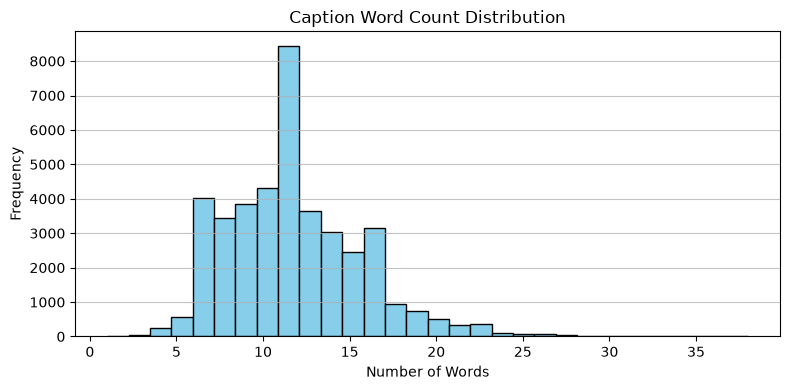

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(df["word_count"], bins=30, color="skyblue", edgecolor="black")
plt.title("Caption Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.tight_layout()
plt.show()

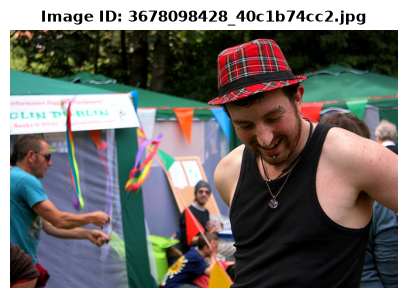

Captions for 3678098428_40c1b74cc2.jpg:
  1. A bearded man at a fair wearing a black tank top and a plaid hat .
  2. A guy with a black tank top .
  3. A man in a black tank top wearing a red plaid hat
  4. A man wearing a black tank top and red plaid hat is smiling as a man behind him is playing with a colorful object .
  5. A man with face peircings and a red fadora hat smiles at a fair .
------------------------------------------------------------


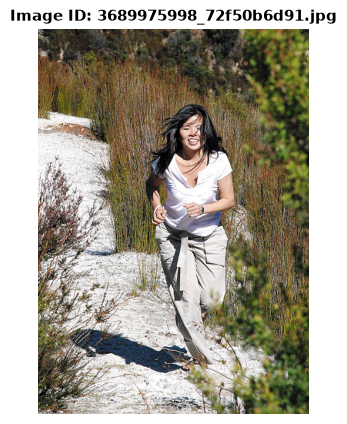

Captions for 3689975998_72f50b6d91.jpg:
  1. An asian girl is running outside .
  2. An Asian woman is running on a rocky path .
  3. A woman runs on a chalk white path .
  4. A woman runs on the beach .
  5. A woman with long black hair and a white shirt is running up the sand and tall weeds .
------------------------------------------------------------


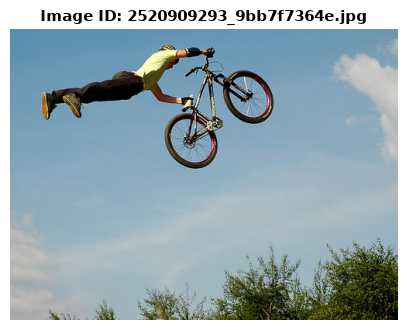

Captions for 2520909293_9bb7f7364e.jpg:
  1. A guy in a yellow shirt with a bike gets very high in the air .
  2. A man in midair holding his bike 's handlebars
  3. A man is performing a trick high in the air with a bicycle .
  4. A man wearing a yellow shirt is doing a trick high in the air with his bike .
  5. Man holding onto bike handlebars while in midair .
------------------------------------------------------------


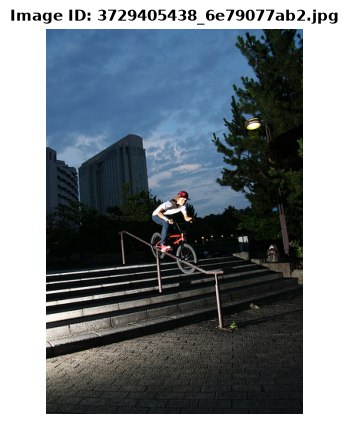

Captions for 3729405438_6e79077ab2.jpg:
  1. A bicycler balances his bike on a rail .
  2. A biker is riding down the stairs on his bike at night .
  3. A boy rides his red bicycle down the handrail of a staircase in a city .
  4. A guy grinding a rail in a park on his bike
  5. A trick bicyclist grinds down a handrail .
------------------------------------------------------------


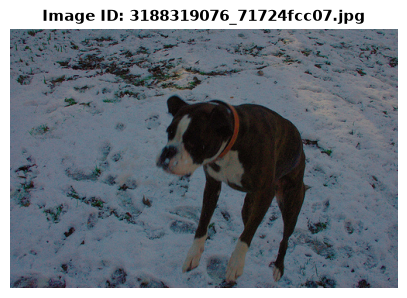

Captions for 3188319076_71724fcc07.jpg:
  1. A black and white dog jumps up and down in the snow .
  2. A boxer leaps in the snow .
  3. A brown and white dog wearing a red collar is standing in the snow .
  4. A dog above snow .
  5. Large dog out in the snow .
------------------------------------------------------------


In [9]:
def show_random_samples(df, images_dir, num_samples=3):
    unique_images = df["image"].unique()
    selected_images = random.sample(list(unique_images), num_samples)

    for img_name in selected_images:
        img_path = os.path.join(images_dir, img_name)
        captions = df[df["image"] == img_name]["caption"].tolist()

        # Display image inline
        if os.path.exists(img_path):
            fig, ax = plt.subplots(figsize=(5, 5))
            img = Image.open(img_path)
            ax.imshow(img)
            ax.axis("off")
            ax.set_title(f"Image ID: {img_name}", fontsize=11, fontweight="bold")
            plt.show()
        else:
            print(f"Warning: Image file not found at {img_path}")

        # Print corresponding captions
        print(f"Captions for {img_name}:")
        for idx, cap in enumerate(captions, 1):
            print(f"  {idx}. {cap}")
        print("-" * 60)

# Run visualization for 3 random samples
show_random_samples(df, IMAGES_DIR, num_samples=5)